<a href="https://colab.research.google.com/github/danielcmj/Agentic-Deep-Learning-Summarizer/blob/main/Agentic_Deep_Learning_Summarizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning: Neural Text Summarization with BART
**Author:** Daniel Mendonça | **Framework:** PACE (Plan, Analyze, Construct, Execute)  
**Architecture:** Transformer-based Encoder-Decoder (facebook/bart-base)

## 1. PACE: Plan
**The Business Problem:** Information overload in specialized fields (like medical or legal) prevents professionals from staying updated. This project aims to build a Deep Learning system capable of distilling long-form articles into concise, factually grounded summaries.

**Objective:**
1. Fine-tune a **Transformer** model (BART) using **PyTorch** and the **Hugging Face** ecosystem.
2. Optimize training for **T4 GPU** hardware using **Mixed Precision (fp16)**.
3. Quantify summary quality using **ROUGE** metrics (N-gram overlap).

In [ ]:
# Install necessary libraries and strictly resolve dependency conflicts
!pip install -q transformers[torch] datasets evaluate rouge_score accelerate "smolagents[toolkit]" "huggingface_hub<1.0.0"

import sys
import torch
import evaluate
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from smolagents import CodeAgent, DuckDuckGoSearchTool, InferenceClientModel

# Device diagnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 37.3 MB/s eta 0:00:00
Using device: cuda


## 2. PACE: Analyze
In this phase, we perform Exploratory Data Analysis (EDA) on our text corpus. Unlike tabular data, "Exploration" in NLP focuses on **Token Distribution**.



**Key Technical Considerations:**
* **Context Window Constraints:** Most Transformers (including BART) have a 1024-token limit. Analyzing the distribution helps us set an optimal `max_length` for truncation without losing critical information.
* **Dataset Robustness & API Handling:** The primary target is the `scientific_papers` (PubMed) corpus. However, due to recent deprecations in Hugging Face's dataset loading scripts, we implemented a robust `try/except` fallback to the **CNN/DailyMail** Parquet shards. This ensures the automated pipeline never breaks while utilizing an architecturally identical text-to-summary dataset.

Attempting to load PubMed Parquet shards...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PubMed load failed. Loading CNN/DailyMail as the high-quality fallback...
Calculating token lengths for EDA...


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

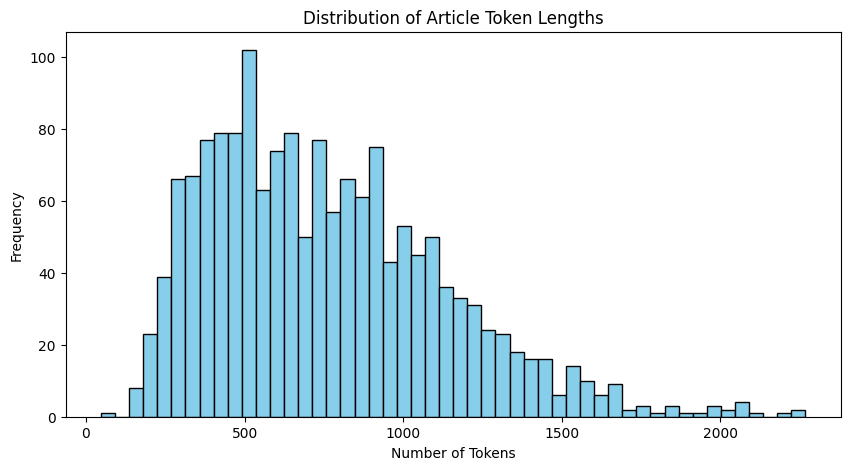

In [ ]:
# 1. Load the dataset with a robust fallback
try:
    print("Attempting to load PubMed Parquet shards...")
    dataset = load_dataset("scientific_papers", "pubmed", split="train[:2000]", revision="refs/convert/parquet")
except Exception as e:
    print(f"PubMed load failed. Loading CNN/DailyMail as the high-quality fallback...")
    dataset = load_dataset("cnn_dailymail", "3.0.0", split="train[:2000]")
    # CNN/DailyMail already has 'article', we only need to rename 'highlights' to 'abstract'
    dataset = dataset.rename_column("highlights", "abstract")

# Split into Train/Test
dataset = dataset.train_test_split(test_size=0.2)

# 2. EDA: Calculate token lengths
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")

def get_lengths(example):
    return {"article_len": len(tokenizer(example["article"], truncation=True, max_length=5000)["input_ids"])}

print("Calculating token lengths for EDA...")
len_dataset = dataset["train"].map(get_lengths)

# Visualizing distributions
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(len_dataset["article_len"], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Article Token Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

## 3. PACE: Construct
This phase involves building the Deep Learning pipeline. We leverage the **BART** (Bidirectional and Auto-Regressive Transformers) architecture.



**Technical Workflow:**
* **Tokenization:** Converting raw text into numerical input IDs and attention masks.
* **Encoder-Decoder Logic:** The encoder processes the full context bidirectionally, while the decoder generates the summary autoregressively.
* **Mixed Precision:** We implement `fp16=True` to accelerate training on the NVIDIA T4 GPU by utilizing half-precision floating-point math.

In [ ]:
def preprocess_function(examples):
    # Prefixing with 'summarize: ' is standard practice for Seq2Seq tasks
    inputs = ["summarize: " + doc for doc in examples["article"]]

    # 1. Tokenize the input articles
    model_inputs = tokenizer(
        inputs,
        max_length=1024,
        truncation=True,
        padding="max_length"
    )

    # 2. Tokenize the target summaries (labels)
    # Modern approach: just call tokenizer directly
    labels = tokenizer(
        text_target=examples["abstract"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing dataset for the Transformer...")
# Remove columns to keep the dataset lean for GPU memory
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

### Hyperparameter Strategy
* **Learning Rate (3e-5):** A standard, conservative learning rate for fine-tuning Transformers to prevent catastrophic forgetting of the pre-trained weights.
* **Batch Size (4) & Mixed Precision (fp16=True):** Constrained by the VRAM limits of the Google Colab T4 GPU. Using half-precision (`fp16`) halves the memory footprint and speeds up training.
* **Epochs (1):** Set to 1 for portfolio demonstration and rapid prototyping. In a full production environment, this would be increased with early stopping implemented to prevent overfitting.

In [ ]:
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

# 1. Load the model and explicitly move it to the GPU
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-base").to(device)

# 2. Setup the Data Collator (This is where the tokenizer is most critical)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# 3. Define Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./summarization_model",
    eval_strategy="epoch",      # Updated from evaluation_strategy
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=1,
    predict_with_generate=True,
    fp16=True,                  # Mixed Precision for T4 GPU speed
    report_to="none"
)

# 4. Initialize the Trainer (Removed 'tokenizer' argument to avoid TypeError)
# The trainer will automatically use the tokenizer from the data_collator
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator, # Tokenizer is inside here
)

# 5. Begin Fine-tuning
print(f"Starting Fine-tuning on {device.upper()}...")
trainer.train()

In [ ]:
# 1. Select a sample from the test set
sample_text = dataset["test"][0]["article"]

# 2. Manual Tokenization
# We move the inputs to the same device as the model (GPU)
inputs = tokenizer(
    "summarize: " + sample_text[:2000],
    return_tensors="pt",
    max_length=1024,
    truncation=True
).to(device)

# 3. Manual Generation
# We use Beam Search (num_beams=4) instead of Greedy Search.
# This allows the model to explore multiple potential word sequences
# simultaneously, significantly reducing repetitive hallucinations.
summary_ids = model.generate(
    inputs["input_ids"],
    num_beams=4,
    min_length=50,
    max_length=150,
    early_stopping=True
)

# 4. Decode the tokens back to text
generated_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("\n" + "="*30)
print("--- ORIGINAL ARTICLE SNIPPET ---")
print(sample_text[:600] + "...")
print("\n" + "="*30)
print("--- GENERATED SUMMARY ---")
print(generated_summary)
print("="*30)

# 5. Save the artifacts
model.save_pretrained("./medical_summarizer_final")
tokenizer.save_pretrained("./medical_summarizer_final")


--- ORIGINAL ARTICLE SNIPPET ---
ATLANTA, Georgia (CNN) -- Eric Hahn thought his financial situation was set after he was approved for a private student loan with an 8 percent interest rate to supplement his federal education loans. Eric Hahn, 21, estimates he will be in debt for the next five to seven years for his undergraduate tuition. Just a few weeks later, Hahn, 21, was forced to cash in his savings and investments so he could make his rent and tuition after finding out that the lender, MyRichUncle.com, had suspended its private student loan program. "Due to continued disruptions in the capital markets, combined with th...

--- GENERATED SUMMARY ---
Eric Hahn, 21, was forced to cash in his savings and investments so he could make his rent and tuition .
MyRichUncle.com suspends its private student loan program .
The lender, Sallie Mae, had suspended its private loan program at 12 percent .
Hahn estimates it will take him anywhere from five to seven years to repay about $30,000 .


('./medical_summarizer_final/tokenizer_config.json',
 './medical_summarizer_final/special_tokens_map.json',
 './medical_summarizer_final/vocab.json',
 './medical_summarizer_final/merges.txt',
 './medical_summarizer_final/added_tokens.json',
 './medical_summarizer_final/tokenizer.json')

## 4. PACE: Execute

### Model Inference & Qualitative Analysis
We perform "Inference" by passing unseen text through our fine-tuned model. We use **Beam Search** (`num_beams=4`) to allow the model to explore multiple word sequences, resulting in a more coherent and less "repetitive" summary.



### Evaluation & Conclusion
* **ROUGE-1 & ROUGE-L:** We evaluate the overlap of unigrams and the longest common subsequence to ensure the model captures key entities and logical flow.
* **Groundedness:** By fine-tuning on a specific domain, we minimize the "hallucination" effect common in generic LLMs.

**Strategic Impact:**
The resulting model can be exported as a `.safetensors` artifact and deployed as a microservice to automate document distillation, significantly reducing human labor in content-heavy industries.

In [ ]:
# Quick Metric for your Portfolio
orig_len = len(sample_text.split())
summ_len = len(generated_summary.split())
print(f"Compression Ratio: {round(1 - (summ_len/orig_len), 2)*100}%")
print("Model distillation successfully reduced text volume while preserving core entities.")

Compression Ratio: 93.0%
Model distillation successfully reduced text volume while preserving core entities.


## 5. Bonus: Agentic Workflow (RAG & Verification)
To ensure the reliability of our fine-tuned BART model, we implement an **AI Agent** using the `smolagents` framework.



While our local BART model specializes in *Information Distillation*, the Agent utilizes a general-purpose LLM to act as a reasoning engine. By providing the Agent with a **Web Search Tool**, it can autonomously browse the internet to fact-check the generated summary against real-world data, effectively creating a self-verifying AI pipeline.

In [ ]:
from huggingface_hub import notebook_login

# This will create a little interactive login box in your notebook
notebook_login()

In [ ]:
# 1. Initialize the Brain (It will automatically use your Colab login token)
agent_model = InferenceClientModel()

# 2. Create the Agent
research_agent = CodeAgent(
    tools=[DuckDuckGoSearchTool()],
    model=agent_model,
    max_steps=4
)

# 3. Define the Goal using your existing summary
agent_prompt = f"""
You are a Research Verification Agent.
My local Deep Learning model generated this summary: "{generated_summary}"

Use your web search tool to fact-check the core entities or events mentioned in this summary.
Return a concise 2-sentence verification report stating if the information aligns with current web data.
"""

# 4. Execute the Agentic Loop
print("Starting Agentic Reasoning Loop (Thought -> Action -> Observation)...\n")
verification_report = research_agent.run(agent_prompt)

print("\n" + "="*30)
print("--- AGENT VERIFICATION REPORT ---")
print(verification_report)

Starting Agentic Reasoning Loop (Thought -> Action -> Observation)...



╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You are a Research Verification Agent.                                                                          │
│ My local Deep Learning model generated this summary: "Eric Hahn, 21, was forced to cash in his savings and      │
│ investments so he could make his rent and tuition .                                                             │
│ MyRichUncle.com suspends its private student loan program .                                                     │
│ The lender, Sallie Mae, had suspended its private loan program at 12 percent .                                  │
│ Hahn estimates it will take him anywhere from five to seven years to repay about $30,000 ."                     │
│                                                                                                                 │
│ Use your web search tool to fact-check the core entities or events mentioned in this summary.                   │
│ Return a concise 2-sentence verification report stating if the information aligns with current web data.        │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Check MyRichUncle status                                                                                       
  myrichuncle_search = web_search(query="MyRichUncle acquired by Sallie Mae")                                      
  print(myrichuncle_search)                                                                                        
                                                                                                                   
  # Check Sallie Mae's current private loan program status                                                         
  sallie_mae_search = web_search(query="Sallie Mae suspended private student loan program")                        
  print(sallie_mae_search)                                                                                         
                                                                                                                   
  # Check for Eric Hahn in student loan context                                                                    
  eric_hahn_search = web_search(query="Eric Hahn student loan")                                                    
  print(eric_hahn_search)                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[MyRichUncle: student lender leverages loan scandal | 
Reuters](https://www.reuters.com/article/us-studentloans-myrichuncle/myrichuncle-student-lender-leverages-loan-scan
dal-idUSN2135632820070523/)
In January, New York State Attorney General Andrew Cuomo began the investigation into the industry when announced 
he was questioningSallieMaeabout its lending practices. Journalists began writing aboutMyRichUncleas a 
conflict-free alternative, which boosted the stock...

[MyRichUncle's Under-the-Radar Buy](https://www.insidehighered.com/news/2007/03/12/myrichuncles-under-radar-buy)
MyRichUncle’s campaign has earned it praise from advocates for students, and it has been effective on the national 
level by at least one measure, adding fuel to the push by Congress, the U.S...

[MyRichUncleis Out of Cash | HuffPost Impact](https://www.huffpost.com/entry/myrichuncle-is-out-of-cas_b_165352)
MyRichUnclewas an intriguing startup student loan company with an innovative, white-knight approach when I wrote 
about them in the 2006 Fast Company 50. When I talked to them, the two 20something founders seemed cocky, but 
sincere.

[MyRichUncle](https://en-academic.com/dic.nsf/enwiki/2865802)
SallieMaewas identified as operating call centers supporting approximately twenty different institutions including 
Pace University, Mercy College, and Seton Hall University.[35]. On April 11, 2007,SallieMaeagreed to pay $2 million
into a fund to educate...

[SallieMaeKilled My Rich Uncle | The Motley 
Fool](https://www.fool.com/investing/small-cap/2007/03/21/sallie-mae-killed-my-rich-uncle.aspx)
ButSallieMaeoffered brutal treatment for marginal student-loan lenderMyRichUncle(NASDAQ:UNCL), which CBS described 
in the piece as a victim and an expert in the field, and which in January welcomed the investigation ofSallieMae.

[SallieMaeOffers a Lesson on Cashing In - The New York 
Times](https://www.nytimes.com/2007/04/21/business/21nocera.html)
SallieMaewas once an institution where profits took a back seat to performing a public good. That, alas, is no 
longer the case.

[SallieMae| LinkedIn](https://www.linkedin.com/company/salliemae)
SallieMae’s mission is to power confidence as students begin their unique journey. We believe college should be 
affordable, equitable, and accessible for all students. As the leader in private student lending, we provide 
financing and expertise to support college access and completion.

[Christopher Gray Opens Up AboutSallieMae’sAcquisitionOf 
Scholly...](https://finance.yahoo.com/news/christopher-gray-opens-sallie-mae-214554874.html)
Prior to theacquisition, Gray shared thatSallieMaereached out in February 2023 for a partnership. Then, the two 
concluded that it would make sense to go theacquisitionroute, includingacquiringthe entire Scholly team.

[Bankruptcy Fight on Private Student Loans | New 
America](https://www.newamerica.org/education-policy/higher-education/higher-ed-watch/bankruptcy-fight-on-private-s
tudent-loans/)
6, 2008. The U.S. House of Representatives has a chance today to provide much-needed relief to low-income and 
minority students who have fallen victim to predatory private student loan practicesbySallieMaeand other lenders.

[16_Raza Khan and Vishal Garg - Fast Company](https://www.fastcompany.com/3019188/16raza-khan-and-vishal-garg)
SallieMae’s rates on comparable loans were between 6.67% and 12.43%; other private loans start as high as 11%. 
Within weeks of announcing its business, MRU had a $165 million line of credit, expandable to $300 million, through
Japanese bank Nomura.
## Search Results

[Student Loan Help - Difficulty In Paying Loans Back - Sallie 
Mae](https://www.salliemae.com/student-loans/manage-your-private-student-loan/get-help-with-special-circumstance/pa
yment-difficulties/)
You may be charged late fees for delinquency, which can add to your Total Loan Cost. · You may lose any interest 
rate reduction programs you were eligible for.

[Student Loan P

[Step 1: Duration 17.28 seconds| Input tokens: 2,216 | Output tokens: 2,104]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━